# Custom Loss Function - Huber Loss

# SetUp

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Custom Huber Loss Function

In [2]:
class CustomHuberLoss(keras.losses.Loss):
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) <= self.delta
        small_error_loss = tf.square(error) / 2
        large_error_loss = self.delta * (tf.abs(error) - self.delta / 2)
        return tf.where(is_small_error, small_error_loss, large_error_loss)

# Load Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


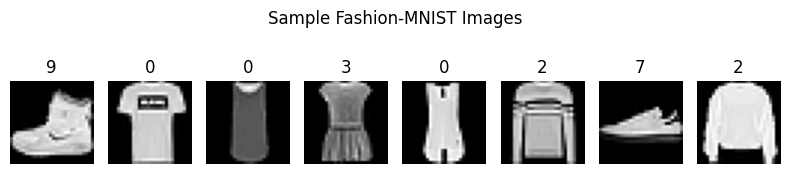

In [4]:
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

# Convert labels to one-hot for regression-style target

In [5]:

num_classes = 10
y_train_oh = tf.one_hot(y_train, depth=num_classes)
y_test_oh = tf.one_hot(y_test, depth=num_classes)

# Model Using Huber Loss

In [6]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam', loss=CustomHuberLoss(delta=1.0), metrics=['accuracy'])

# Train and Evaluate

In [7]:
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=64, validation_data=(x_test, y_test_oh), verbose=2)

Epoch 1/5
938/938 - 7s - 7ms/step - accuracy: 0.8159 - loss: 0.0166 - val_accuracy: 0.8471 - val_loss: 0.0132
Epoch 2/5
938/938 - 4s - 4ms/step - accuracy: 0.8657 - loss: 0.0114 - val_accuracy: 0.8575 - val_loss: 0.0114
Epoch 3/5
938/938 - 5s - 6ms/step - accuracy: 0.8783 - loss: 0.0100 - val_accuracy: 0.8697 - val_loss: 0.0103
Epoch 4/5
938/938 - 9s - 9ms/step - accuracy: 0.8855 - loss: 0.0093 - val_accuracy: 0.8721 - val_loss: 0.0099
Epoch 5/5
938/938 - 5s - 6ms/step - accuracy: 0.8899 - loss: 0.0087 - val_accuracy: 0.8671 - val_loss: 0.0101


# Plotting Results

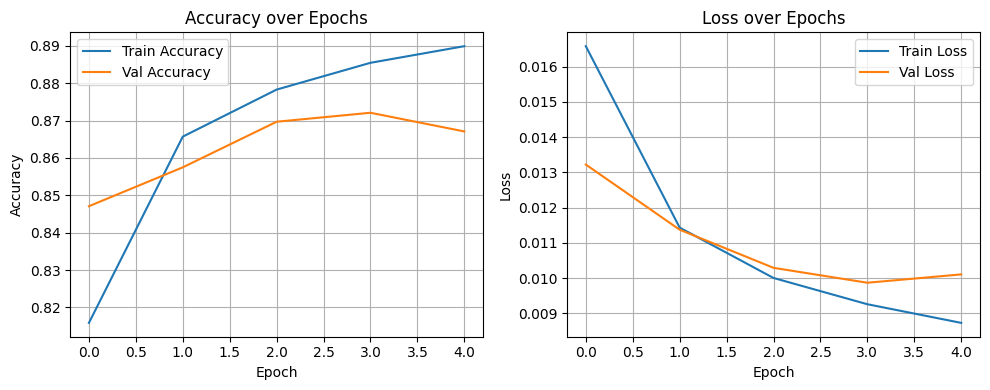

✅ Training with Custom Huber Loss completed successfully.


In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("✅ Training with Custom Huber Loss completed successfully.")